In [1]:
import numpy as np

# import sasmodels
import sasmodels
import sasmodels.core
import sasmodels.data
import sasmodels.bumps_model

import sasdata

from sasdata.dataloader.loader import Loader
from sasmodels.data import load_data
#from sas import sascalc.dataloader

from sasmodels.data import plot_theory

import bumps
import bumps.fitters
import bumps.names
import bumps.fitproblem

import os

In [2]:
"""
import matplotlib.pyplot and set custom default settings for plots
"""
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import matplotlib.pyplot as plt

plt.rc('font', size=14) # default fontsize
plt.rc('axes', titlesize=16)
plt.rc('axes', labelsize=16)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)
plt.rc('legend', title_fontsize=14)
plt.rc('figure', titlesize=18)
plt.rc("figure", figsize=(5,5))
plt.rc("lines", linewidth=3)

# this one is for 2D SAXS images
plt.rc('image', cmap='jet')

total number of data points:  1015
after skip at low and large q values: 395
after slicing: 198


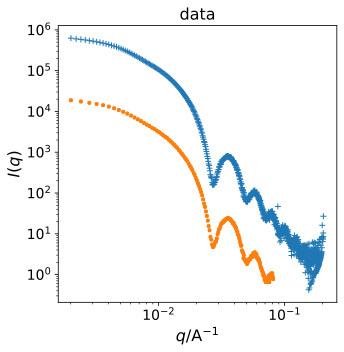

In [3]:
filename="./data-examples/0V_00228.dat"

# Number of lines in the header 
skipheader=50 

data_np = np.genfromtxt(filename, skip_header=skipheader)
data_np = data_np[~np.isnan(data_np[:, 1])] # Clean NaNs to prevent crashes

total_data_number = data_np.shape[0]
print('total number of data points: ', total_data_number)

plt.loglog(data_np[:,0], data_np[:,1], '+')

# Skip low and high q as per your template
skipmin=0
skipmax=620
number_of_data = total_data_number - skipmax - skipmin

print('after skip at low and large q values:', number_of_data)

slicing_step=2 
rescale=0.03
coeff=0.1

data = sasmodels.data.Data1D(x=data_np[0:number_of_data:slicing_step,0], 
                             y=rescale*data_np[0:number_of_data:slicing_step,1], 
                             dy=rescale*coeff*data_np[0:number_of_data:slicing_step,1])

number_of_data_new = data.x.shape[0]
print('after slicing:', number_of_data_new)

sasmodels.data.plot_data(data)

In [4]:
newfilename=filename[:-4]+"_new.dat" # data 

with open(newfilename, "w") as f:
    f.write("raw data file is:"+filename+"\n")
    f.write("number of data points: \t"+str(number_of_data_new)+"\n")

with open(newfilename, "a") as fa:
    for i in range(0,number_of_data_new):
        line_to_write=str(data.x[i])+"\t"+str(data.y[i])+"\t"+str(data.dy[i])+"\n"
        fa.write(line_to_write)

In [5]:

kernel = sasmodels.core.load_model("sphere")
params = {} 
model = sasmodels.bumps_model.Model(kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

In [6]:

kernel.info.parameters.defaults

{'scale': 1,
 'background': 0.001,
 'sld': 1,
 'sld_solvent': 6,
 'radius': 50,
 'up_frac_i': 0.0,
 'up_frac_f': 0.0,
 'up_theta': 90.0,
 'up_phi': 0.0,
 'sld_M0': 0.0,
 'sld_mtheta': 0.0,
 'sld_mphi': 0.0,
 'sld_solvent_M0': 0.0,
 'sld_solvent_mtheta': 0.0,
 'sld_solvent_mphi': 0.0}

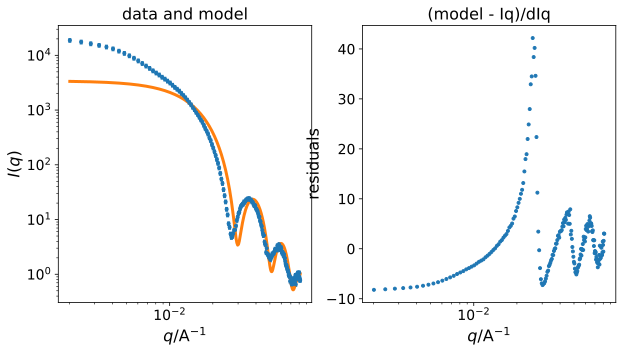

In [ ]:
sld_silver=77.9
sld_water=9.47

params = {
    "radius": 150,                
    "radius_pd_type": 'gaussian',
    "radius_pd": 0.05,
    "radius_pd_n": 8,
    "radius_pd_nsigma": 4,
    "sld": sld_silver,
    "sld_solvent": sld_water,
    "background": 0.05,
    "scale": 0.0005
}

model = sasmodels.bumps_model.Model(model=kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

plt.figure(figsize=(10,5))
experiment.plot()

step 1 cost 87.672(24)
                              background |.........       0.02 in [0.02, 0.2]
                                  radius |.........        100 in [100, 170]
                               radius_pd |.........       0.01 in [0.01, 0.1]
                                   scale .........|      0.009 in [0.0001, 0.009]
step 9 cost 62.498(24) [final]
                              background .........|        0.2 in [0.02, 0.2]
                                  radius ....|.....    129.048 in [100, 170]
                               radius_pd ......|...  0.0702926 in [0.01, 0.1]
                                   scale .........|      0.009 in [0.0001, 0.009]
time 100.7 milliseconds


d:\LPS Internship\.venv\Lib\site-packages\bumps\fitproblem.py:758: UserWarning: Unsatisfied constraints: [background=0.001 is outside (np.float64(0.02), np.float64(0.2)),
radius=50.0 is outside (np.float64(100.0), np.float64(170.0)),
radius_pd=0.0 is outside (np.float64(0.01), np.float64(0.1)),
scale=1.0 is outside (np.float64(0.0001), np.float64(0.009))]
  warnings.warn("Unsatisfied constraints: [%s]" % (",\n".join(broken)))


Fit results for problem: χ² = 62.498(24)
=== Uncertainty from curvature:     name   value(unc.) ===
                              background   0.200(14)      
                                  radius   129.0(1.1)     
                               radius_pd   0.070(13)      
                                   scale   0.00900(46)    
                              background .........|        0.2 in [0.02, 0.2]
                                  radius ....|.....    129.048 in [100, 170]
                               radius_pd ......|...  0.0702926 in [0.01, 0.1]
                                   scale .........|      0.009 in [0.0001, 0.009]
{'scale': 0.009, 'background': 0.2, 'sld': 1.0, 'sld_solvent': 6.0, 'radius': 129.0476420022907, 'radius_pd': 0.07029258938971072, 'radius_pd_n': 35.0, 'radius_pd_nsigma': 3.0, 'up_frac_i': 0.0, 'up_frac_f': 0.0, 'up_theta': 90.0, 'up_phi': 0.0, 'sld_M0': 0.0, 'sld_mtheta': 0.0, 'sld_mphi': 0.0, 'sld_solvent_M0': 0.0, 'sld_solvent_mtheta': 0.0, 's

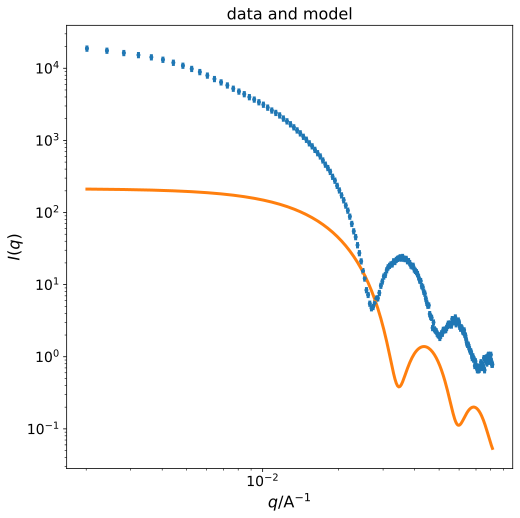

In [7]:
# list of the fitting parameters with their fitting range
model.scale.range(0.0001, 0.009)
model.background.range(0.02, 0.2)
model.radius.range(100, 170)
model.radius_pd.range(0.01, 0.1)



problem = bumps.fitproblem.FitProblem(experiment)

results = bumps.fitters.fit(problem, 
                            method='lm', 
                            steps=10, 
                            ftol=1.5e-06, 
                            xtol=1.5e-06, 
                            verbose=True)

plt.figure(figsize=(8,8))
print(problem.summarize())
print(model.state())
print(problem.chisq())
sasmodels.data.plot_theory(data, experiment.Iq_calc)

In [8]:
fitfilename=filename[:-4]+"_fit.dat" # fit 

with open(fitfilename, "w") as f:
    f.write("raw data file is:"+filename+"\n")
    f.write("number of data points: \t"+str(number_of_data_new)+"\n")

with open(fitfilename, "a") as fa:
    for i in range(0,number_of_data_new-1):
        line_to_write=str(data.x[i])+"\t"+str(experiment.Iq_calc[i])+"\n"
        fa.write(line_to_write)

62.497858158582396


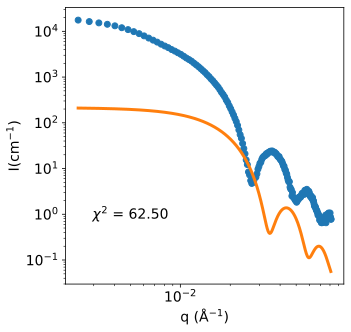

In [9]:
data_final = np.loadtxt(newfilename, skiprows=3)
fit_final = np.loadtxt(fitfilename, skiprows=3)

plt.loglog(data_final[:,0], data_final[:,1], 'o')
plt.loglog(fit_final[:,0], fit_final[:,1])
plt.xlabel('q '+r'(Å$^{-1}$)',fontsize=14)
plt.ylabel('I'+r'(cm$^{-1}$)',fontsize=14)
plt.text(0.005, 0.8, r'$\chi^2$ = '+f"{problem.chisq():.2f}", fontsize=14, horizontalalignment='center')
print(problem.chisq())